Real-Time Sign Language Recognition System
By Esther Aneno

Problem Statement

Communication between deaf or hard-of-hearing individuals and those who do not understand sign language remains a major barrier, especially in education, healthcare, and workplaces. In Uganda, systemic inequalities and limited access to sign language interpreters worsen this challenge, leading to exclusion and reduced opportunities for people with hearing impairments. During my time at Effatha Vocational School for the Deaf, I observed a critical communication gap between deaf students and qualified teachers who are not proficient in sign language, highlighting the urgent need for an accessible, real-time solution.

In [35]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [29]:
#Loaded Dataset

df = pd.read_csv("dataset.csv")
df.head()

,A,0.47920745611190796,0.786283016204834,-7.346091024373891e-07,0.6082860827445984,0.7047691345214844,-0.029157448559999466,0.6822319626808167,0.5685814619064331,-0.029513586312532425,...,-0.023639118298888206,0.3906998634338379,0.47419270873069763,-0.04674820974469185,0.4115903973579407,0.540363073348999,-0.020417815074324608,0.41034215688705444,0.5603166222572327,0.0046769496984779835
0,A,0.479207,0.786283,-7.346091e-07,0.608286,0.704769,-0.029157,0.682232,0.568581,-0.029514,...,-0.023639,0.390700,0.474193,-0.046748,0.411590,0.540363,-0.020418,0.410342,0.560317,0.004677
1,A,0.357163,0.936787,-6.453583e-07,0.467834,0.839173,-0.022577,0.517769,0.707079,-0.023211,...,-0.017585,0.236143,0.650379,-0.042525,0.261365,0.708943,-0.022221,0.269480,0.740681,0.000244
2,A,0.545224,0.955560,-1.103517e-06,0.707236,0.892580,-0.036403,0.821355,0.751610,-0.035590,...,-0.021674,0.480617,0.578575,-0.055000,0.489606,0.667478,-0.023977,0.480928,0.684798,0.006254
3,A,0.357163,0.936787,-6.453583e-07,0.467834,0.839173,-0.022577,0.517769,0.707079,-0.023211,...,-0.017585,0.236143,0.650379,-0.042525,0.261365,0.708943,-0.022221,0.269480,0.740681,0.000244
4,A,0.456913,0.904678,-7.073182e-07,0.574918,0.808962,-0.029107,0.630824,0.673718,-0.030353,...,-0.017700,0.345385,0.617737,-0.043701,0.370459,0.680143,-0.020508,0.373176,0.703095,0.004127


In [18]:
df.rename(columns={df.columns[0]: 'label'}, inplace=True)

X = df.drop("label", axis=1)
y = df["label"]

## Data Description

- The dataset contains hand landmark features extracted from images.
- Each row represents a hand gesture.
- The first column contains the label (A, B, C, etc.).
- The remaining columns contain numerical landmark values.

In [ ]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [19]:
#Training Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [21]:
y_pred = model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9895397489539749
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        20
           B       1.00      1.00      1.00        20
           C       1.00      1.00      1.00        21
           D       1.00      1.00      1.00        21
           E       0.95      1.00      0.98        20
           F       1.00      1.00      1.00        21
           G       0.91      1.00      0.95        20
           H       1.00      1.00      1.00        20
           I       1.00      1.00      1.00        20
           K       0.95      1.00      0.98        20
           L       1.00      1.00      1.00        20
           M       1.00      0.95      0.97        19
           N       1.00      1.00      1.00        20
           O       1.00      1.00      1.00        20
           P       1.00      0.89      0.94        19
           Q       1.00      1.00      1.00        20
           R       1.00      0.95      0.97        1

In [28]:
joblib.dump(model, "C:\\sign-language-translator\\model.pkl")

['C:\\sign-language-translator\\model.pkl']

In [36]:
cm = confusion_matrix(y_test, y_pred)

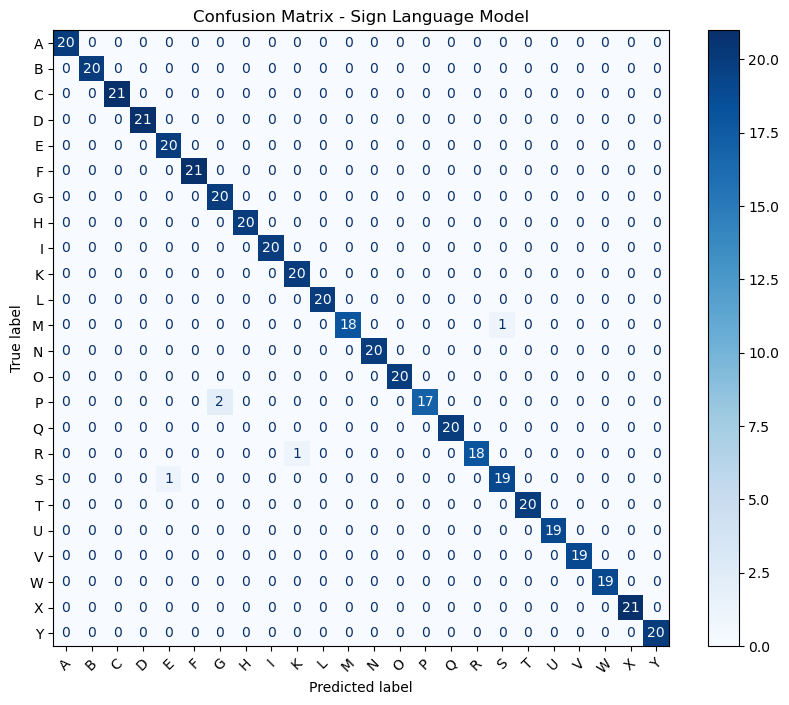

In [37]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Sign Language Model")
plt.show()

The confusion matrix shows strong diagonal dominance, indicating that the model correctly classifies most sign language letters. Only a few misclassifications occur between similar gestures, demonstrating high model reliability.